In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
data_set = pd.read_csv(r"C:\Users\HP\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
data_set.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data_set.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
data_set.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
data_set['TotalCharges'] = pd.to_numeric(data_set['TotalCharges'],errors = 'coerce')

In [8]:
data_set.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
data_set['TotalCharges'].skew()

np.float64(0.961642499724251)

In [10]:
data_set['TotalCharges'].fillna(data_set['TotalCharges'].median(),inplace = True)

C:\Users\HP\AppData\Local\Temp\ipykernel_17392\576541475.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_set['TotalCharges'].fillna(data_set['TotalCharges'].median(),inplace = True)


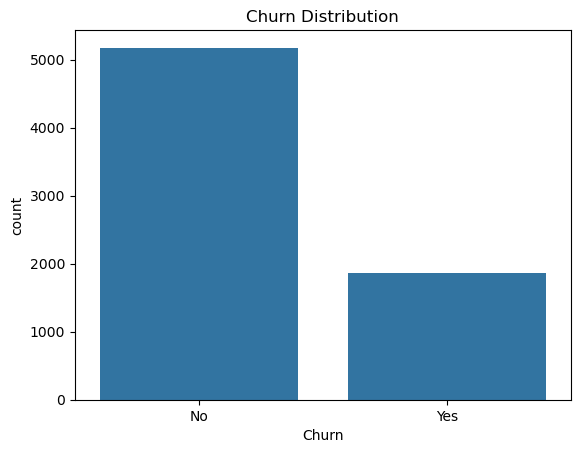

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [11]:
sns.countplot(x='Churn', data=data_set)
plt.title("Churn Distribution")
plt.show()

# Percentage
data_set['Churn'].value_counts(normalize=True) * 100

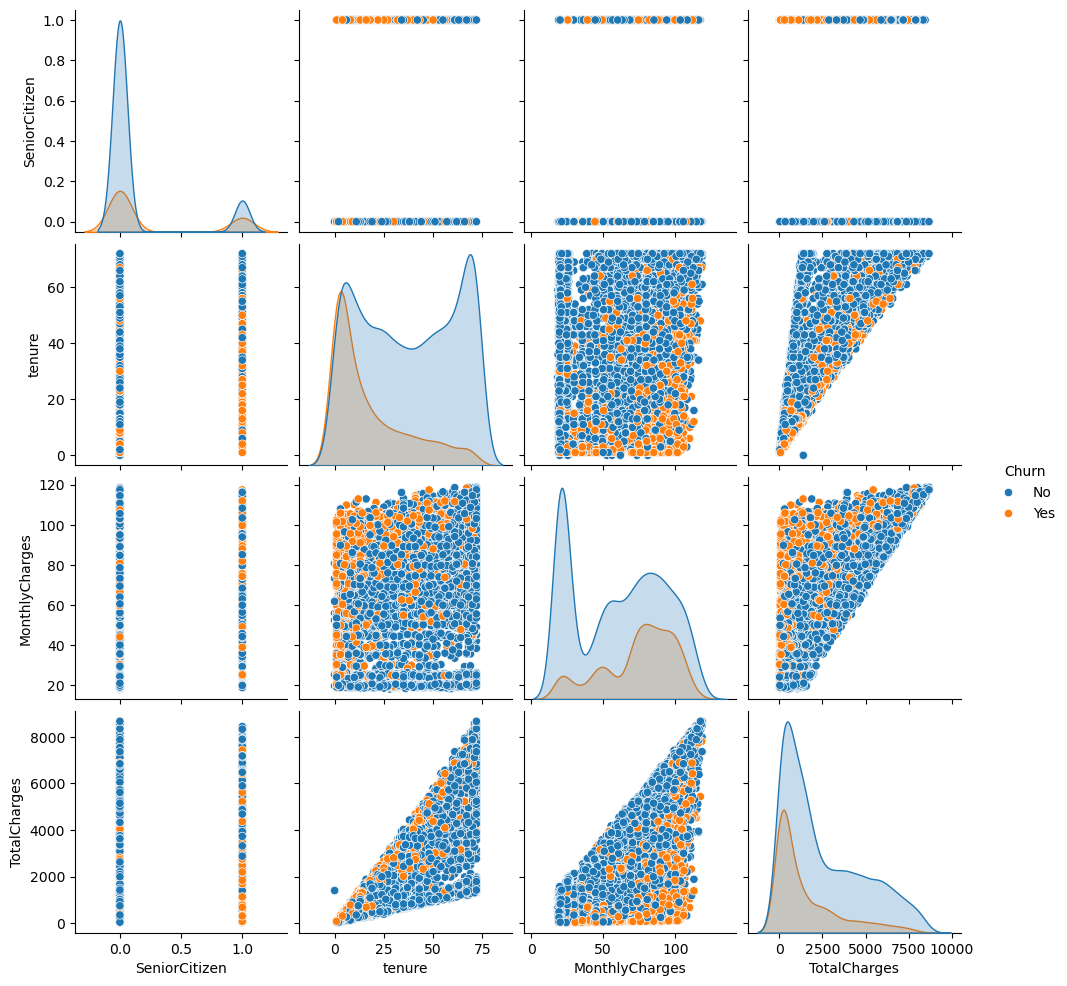

In [12]:
##Exploitart data analysis
sns.pairplot(data_set,hue = 'Churn')
plt.savefig("pairplot.png")
plt.show()

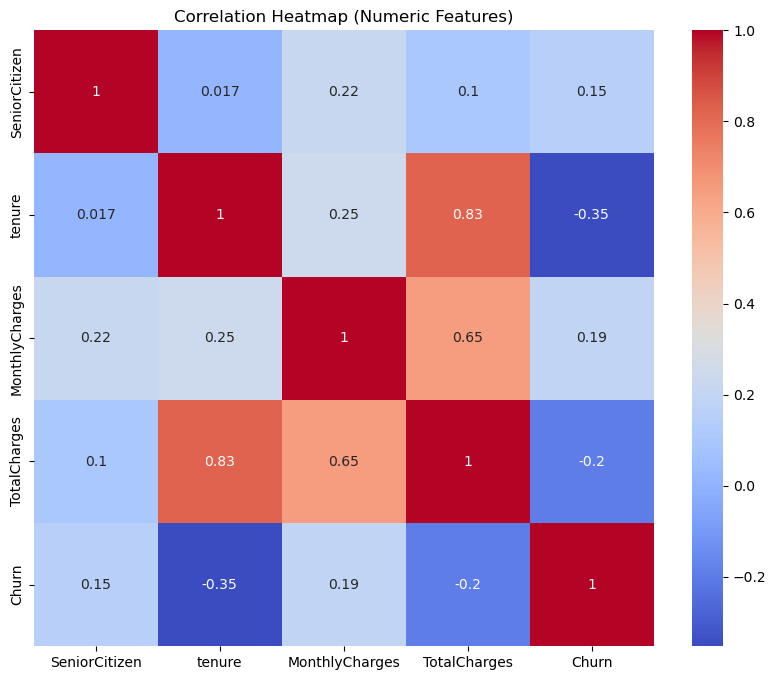

In [13]:
data_set['Churn'] = data_set['Churn'].map({'Yes': 1, 'No': 0})
num_data = data_set.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(num_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

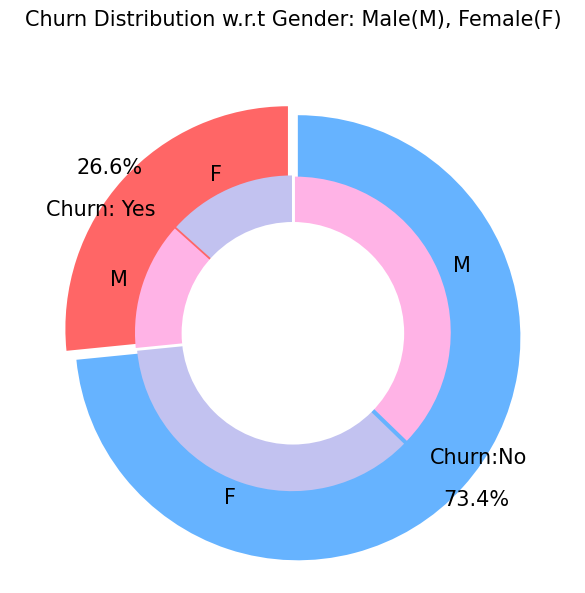

In [14]:
plt.figure(figsize=(6, 6))
labels =["Churn: Yes","Churn:No"]
values = [1869,5163]
labels_gender = ["F","M","F","M"]
sizes_gender = [939,930 , 2544,2619]
colors = ['#ff6666', '#66b3ff']
colors_gender = ['#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6']
explode = (0.3,0.3) 
explode_gender = (0.1,0.1,0.1,0.1)
textprops = {"fontsize":15}
#Plot
plt.pie(values, labels=labels,autopct='%1.1f%%',pctdistance=1.08, labeldistance=0.8,colors=colors, startangle=90,frame=True, explode=explode,radius=10, textprops =textprops, counterclock = True, )
plt.pie(sizes_gender,labels=labels_gender,colors=colors_gender,startangle=90, explode=explode_gender,radius=7, textprops =textprops, counterclock = True, )
#Draw circle
centre_circle = plt.Circle((0,0),5,color='black', fc='white',linewidth=0)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Churn Distribution w.r.t Gender: Male(M), Female(F)', fontsize=15, y=1.1)

# show plot 
 
plt.axis('equal')
plt.tight_layout()
plt.show()

In [15]:
fig = px.histogram(data_set, x="Churn", color = "Contract", barmode = "group", title = "<b>Customer contract distribution<b>")
fig.update_layout(width=700, height=500, bargap=0.2)
fig.show()

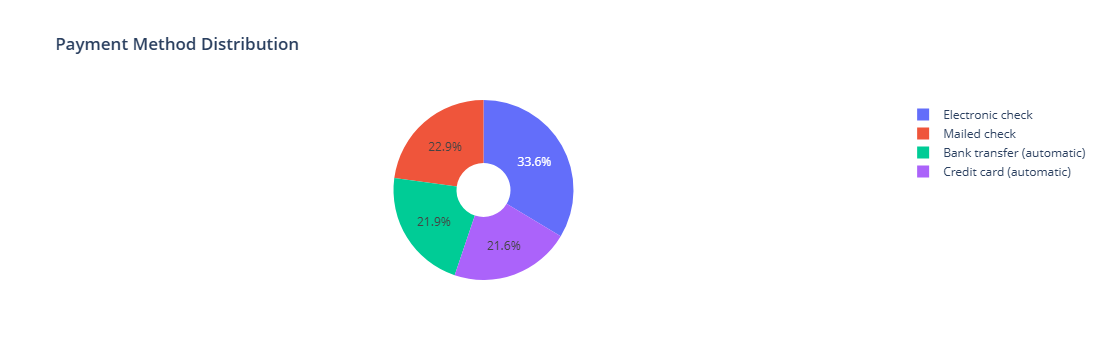

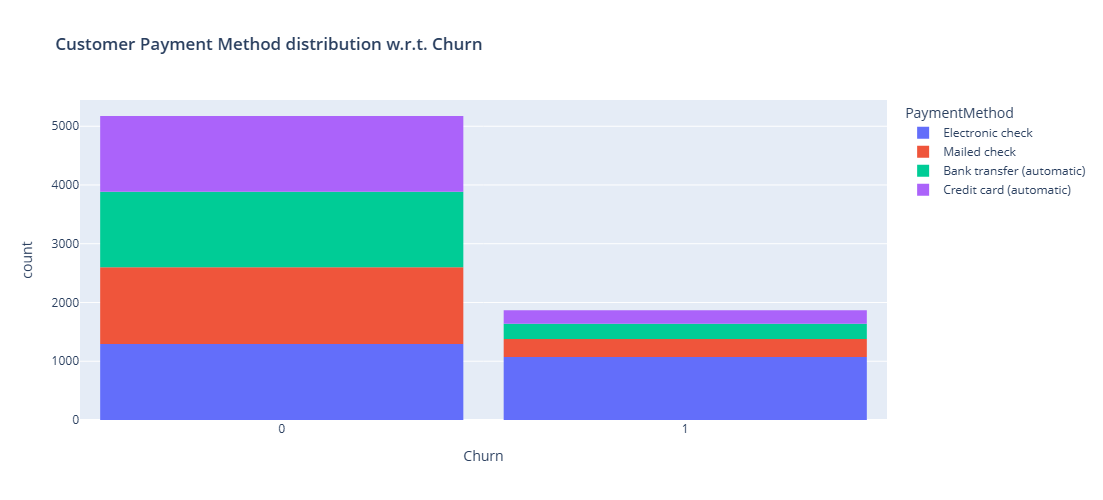

In [16]:
labels = data_set['PaymentMethod'].unique()
values = data_set['PaymentMethod'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Payment Method Distribution</b>")
fig.show()

fig = px.histogram(data_set, x="Churn", color="PaymentMethod", title="<b>Customer Payment Method distribution w.r.t. Churn</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

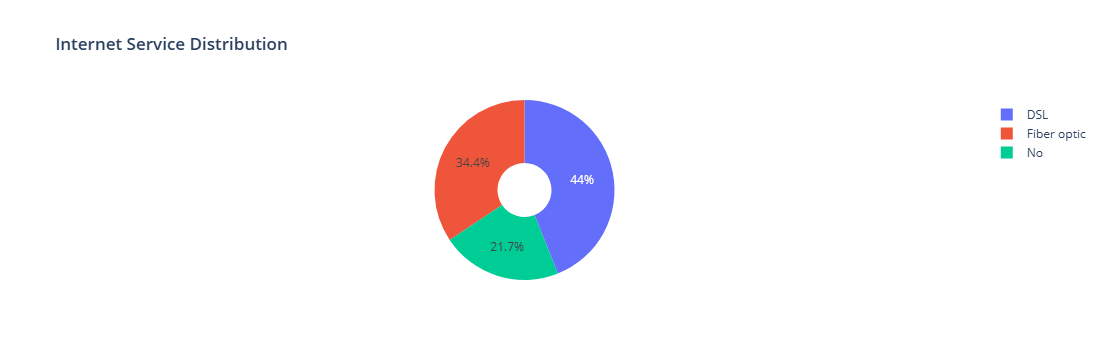

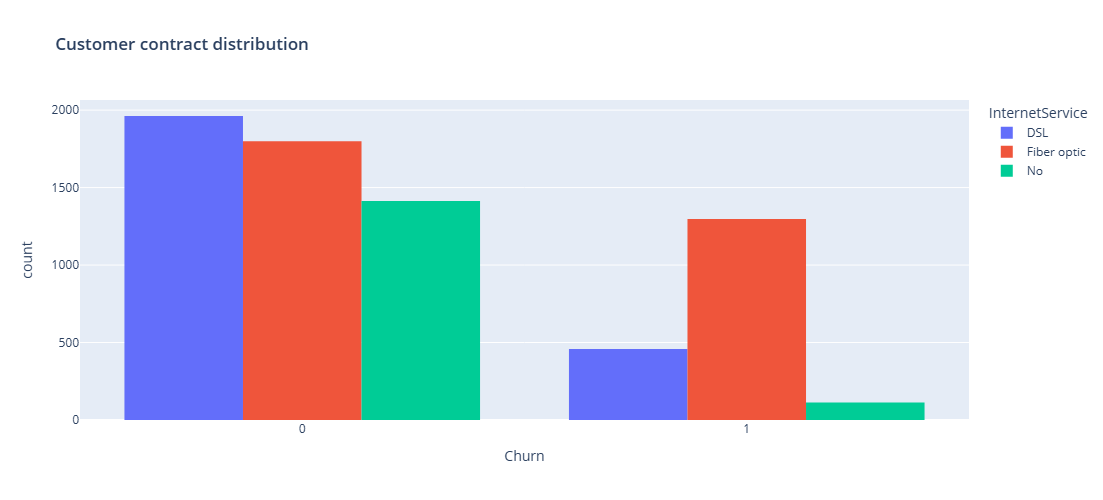

In [17]:
labels = data_set['InternetService'].unique()
values = data_set['InternetService'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Internet Service Distribution</b>")
fig.show()
fig = px.histogram(data_set, x="Churn", color = "InternetService", barmode = "group", title = "<b>Customer contract distribution<b>")
fig.update_layout(width=700, height=500, bargap=0.2)
fig.show()


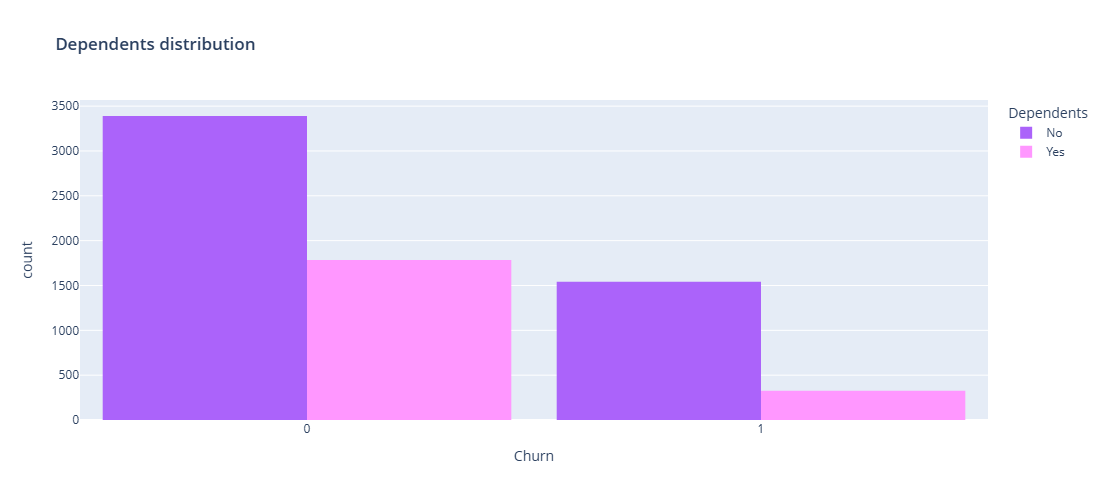

In [18]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(data_set, x="Churn", color="Dependents", barmode="group", title="<b>Dependents distribution</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [19]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(data_set, x="Churn", color="gender", barmode="group", title="<b>Dependents distribution</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

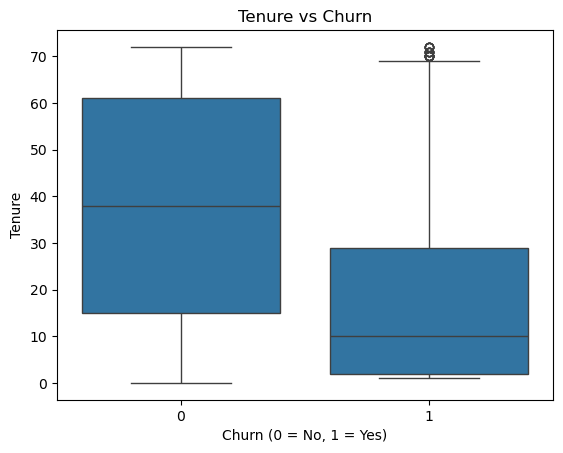

In [20]:
sns.boxplot(x='Churn', y='tenure', data=data_set)
plt.title("Tenure vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_17392\2872285171.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



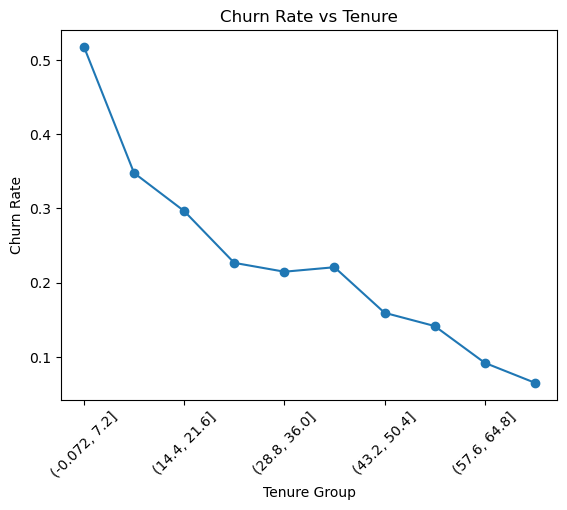

In [21]:
# Create tenure bins
data_set['tenure_group'] = pd.cut(data_set['tenure'], bins=10)

# Compute churn rate
churn_rate = data_set.groupby('tenure_group')['Churn'].mean()

# Plot
churn_rate.plot(kind='line', marker='o')
plt.title("Churn Rate vs Tenure")
plt.ylabel("Churn Rate")
plt.xlabel("Tenure Group")
plt.xticks(rotation=45)
plt.show()

In [22]:
import os
import sys
sys.path.append(r"C:\Users\HP\Linear Regression\Telco customer churn\src")

In [23]:
from model import train_model

In [24]:
results = train_model(data_set)

Training log_reg...
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409

Training dec_tree...
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.56      0.72      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409

Training random_for...
              precision    recall  f1-score   support

           0       0.88      0.81      0.85      1035
           1       0.57      0.70      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted a

In [25]:
import sys

print(sys.executable)

C:\Users\HP\anaconda3\python.exe


In [26]:
results = pd.DataFrame(results)

In [27]:
results

,model,best_params,recall,f1_score,roc_auc_score,best_model
0,log_reg,{'model__C': 10},0.737968,0.621622,0.840538,"(ColumnTransformer(transformers=[('num',\n ..."
1,dec_tree,"{'model__max_depth': 5, 'model__min_samples_sp...",0.716578,0.626168,0.831799,"(ColumnTransformer(transformers=[('num',\n ..."
2,random_for,"{'model__max_depth': 5, 'model__n_estimators':...",0.703209,0.632212,0.839089,"(ColumnTransformer(transformers=[('num',\n ..."
3,grad_boost,"{'model__learning_rate': 0.1, 'model__n_estima...",0.799465,0.634820,0.843385,"(ColumnTransformer(transformers=[('num',\n ..."
4,XGB,{'model__colsample_bytree': 0.9065499702296098...,0.770053,0.637874,0.846208,"(ColumnTransformer(transformers=[('num',\n ..."
